# Where do Hamburg's train delays come from?

**Data:** 1.5 million train stops at Hamburg's four main stations (Hbf, Dammtor, Altona, Harburg), October 2024 – September 2025, from Deutsche Bahn's Timetables API ([piebro/deutsche-bahn-data](https://github.com/piebro/deutsche-bahn-data), CC BY 4.0).

**Questions**
1. How punctual is each kind of train — S-Bahn, regional, long-distance — at each station?
2. When during the day does punctuality drop?
3. Are long-distance delays created in Hamburg, or do trains arrive already late?
4. Which regional and S-Bahn lines are the least reliable?

**Approach:** every question is answered twice — once in SQL (SQLite, queries in `../sql/`) and once in pandas — and the two results are checked against each other.

**Definition:** a stop counts as *on time* when the train is less than 6 minutes late, following Deutsche Bahn's official punctuality threshold. Canceled stops have no delay and are reported separately as a cancellation rate.

In [1]:
import re
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR, SQL_DIR, IMG_DIR = ROOT / "data" / "raw", ROOT / "sql", ROOT / "images"
DB_PATH = ROOT / "data" / "hamburg.db"
IMG_DIR.mkdir(exist_ok=True)

pd.set_option("display.width", 140)

def sql(name, con=None):
    # Run a query file from ../sql and return a DataFrame.
    return pd.read_sql((SQL_DIR / name).read_text(), con or conn)

# Chart style: one colour per train category, used identically in every chart.
COLORS = {"Long-distance": "#2a78d6", "Regional": "#eb6834", "S-Bahn": "#1baf7a"}
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "DejaVu Sans", "font.size": 10.5, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 14, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})

def subtitle(ax, text):
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK2, fontsize=10, va="bottom")

## 1. Load the raw data into SQLite

The data comes as one Parquet file per month, already filtered to the four Hamburg stations by `scripts/fetch_data.py`. Everything goes into one SQLite table, `raw_stops`, exactly as delivered.

In [2]:
raw = pd.concat(
    [pd.read_parquet(f) for f in sorted(RAW_DIR.glob("hamburg_stops_*.parquet"))],
    ignore_index=True,
)
print(f"{len(raw):,} rows, {raw.shape[1]} columns")

conn = sqlite3.connect(DB_PATH)
raw.to_sql("raw_stops", conn, if_exists="replace", index=False)
raw.head(3).T

1,514,046 rows, 13 columns


,0,1,2
station,Hamburg-Harburg,Hamburg Dammtor,Hamburg-Altona
train_name,ICE 782,S 5,NBE RB71
final_destination_station,Hamburg Hbf,Hamburg-Ohlsdorf,Hamburg-Altona
delay_in_min,13,6,6
time,2024-10-01 00:07:00,2024-10-01 00:05:00,2024-10-01 00:03:00
is_canceled,False,False,False
train_type,ICE,S,NBE
train_line_ride_id,-1290839640796586839-2409301819,4524183904094312236-2409302343,-3542565668803871763-2409302302
train_line_station_num,12,7,10
arrival_planned_time,2024-09-30 23:52:00,2024-09-30 23:58:00,2024-09-30 23:57:00


## 2. Data quality checks (SQL)

Before computing any average, three checks: is every month there, which rows can't be trusted, and are the labels consistent?

In [3]:
coverage = sql("01_rows_per_month.sql")
coverage

,month,stops,days_with_data,hbf,dammtor,altona,harburg
0,2024-10,138652,31,57227,21554,35874,23997
1,2024-11,137660,30,57313,21594,36309,22444
2,2024-12,143290,31,59966,23684,36689,22951
3,2025-01,142125,31,59478,22779,36858,23010
4,2025-02,129586,28,53634,22079,32876,20997
5,2025-04,135124,30,54576,22355,35302,22891
6,2025-05,143725,31,59447,22812,37662,23804
7,2025-06,137694,30,57685,22135,35206,22668
8,2025-07,141785,31,59313,20425,38224,23823
9,2025-08,131331,31,55709,17507,33518,24597


**Finding: March 2025 is missing.** The source file for that month contains only 3 rows in total, so it was dropped at download. Every other month has data for every day. Results below therefore cover 11 months, and the month-by-month view has a gap rather than a zero.

In [4]:
sql("02_quality_flags.sql").T.rename(columns={0: "rows"})

,rows
total_rows,1514046
replacement_buses,4580
canceled_stops,58183
early_by_up_to_30_min,49795
impossible_early,375
over_12h_late,0
no_arrival_time_origin_stops,187068
no_departure_time_final_stops,184654


What these mean and what I do with them:

| Issue | Decision |
|---|---|
| Replacement buses (`Bus`) | Removed — they are not trains and follow different rules. |
| Canceled stops | Kept for the cancellation rate, but their delay is set to missing. The source still carries a delay value for them, which is meaningless for a train that never came. |
| Early by up to 30 min | Kept, counted as 0 minutes late. Passengers don't experience "negative delay". |
| Impossible early (< −30 min) | Removed. Checking the timestamps shows the changed time is on the wrong day (e.g. −1,432 min = 24 h minus 8 min), a date error in the feed. |
| Over 12 h late | Removed as implausible. |
| Missing arrival or departure time | Expected: a train has no arrival at its first stop and no departure at its last. |

One more check: `delay_in_min` is not documented as arrival or departure delay. Recomputing it from the timestamps shows it matches **departure delay where a departure exists, otherwise arrival delay**, for 100% of rows:

In [5]:
dep = (raw.departure_change_time - raw.departure_planned_time).dt.total_seconds() / 60
arr = (raw.arrival_change_time - raw.arrival_planned_time).dt.total_seconds() / 60
match = (dep.fillna(arr) == raw.delay_in_min).mean()
print(f"delay_in_min == departure delay (fallback: arrival delay): {match:.1%} of rows")

delay_in_min == departure delay (fallback: arrival delay): 100.0% of rows


In [6]:
sql("03_line_name_variants.sql")

,train_type,train_name,stops
0,RE,RE 7,40726
1,RB,RB 81,29024
2,ME,ME RB41,28828
3,ME,ME RB31,28166
4,ME,ME RE3,24117
5,NBE,NBE RB61,23246
6,RE,RE 70,22559
7,ME,ME RE4,21961
8,NBE,NBE RB71,15879
9,RE,RE 5,15645


The same line appears under different labels: operator prefixes (`ME` = metronom, `NBE` = nordbahn) and inconsistent spacing (`RE 7` vs `ME RE3`). I normalise them to one format (`RE7`, `RB41`, `S1`).

## 3. Cleaning (pandas)

In [7]:
LONG_DISTANCE = {"ICE", "IC", "EC", "EN", "NJ", "FLX", "D", "RDC", "UEX"}

def normalise_line(name: str) -> str:
    # 'ME RE3' -> 'RE3', 'RE 7' -> 'RE7', 'S 1' -> 'S1', 'ICE 886' -> 'ICE'
    parts = name.split()
    if re.match(r"^(RE|RB|S)\d", parts[-1]):
        return parts[-1]
    if len(parts) >= 2 and parts[-2] in ("RE", "RB", "S"):
        return parts[-2] + parts[-1]
    return parts[0]

steps = [("raw rows", len(raw))]

df = raw[raw.train_type != "Bus"].copy()
steps.append(("after removing replacement buses", len(df)))

bad_delay = ~df.is_canceled & ~df.delay_in_min.between(-30, 720)
df = df[~bad_delay]
steps.append(("after removing impossible delays", len(df)))

df["category"] = np.select(
    [df.train_type == "S", df.train_type.isin(LONG_DISTANCE)],
    ["S-Bahn", "Long-distance"], default="Regional",
)
df["line"] = df.train_name.astype(str).map(normalise_line)
df["delay_min"] = df.delay_in_min.clip(lower=0).astype("float").where(~df.is_canceled)
df["on_time"] = (df.delay_min < 6).astype("float").where(df.delay_min.notna())
df["is_canceled"] = df.is_canceled.astype(int)

stops = df.rename(columns={"train_line_station_num": "stop_number"})[
    ["station", "category", "train_type", "line", "train_line_ride_id",
     "stop_number", "time", "delay_min", "on_time", "is_canceled"]
].reset_index(drop=True)
stops["time"] = stops.time.dt.strftime("%Y-%m-%d %H:%M:%S")

stops.to_sql("stops", conn, if_exists="replace", index=False)
print(pd.DataFrame(steps, columns=["step", "rows"]).to_string(index=False))
print(f"\nRemoved: {steps[0][1] - steps[-1][1]:,} rows ({1 - steps[-1][1] / steps[0][1]:.2%})")
stops.category.value_counts()

                            step    rows
                        raw rows 1514046
after removing replacement buses 1509466
after removing impossible delays 1509091

Removed: 4,955 rows (0.33%)


category
S-Bahn           1017296
Regional          302643
Long-distance     189152
Name: count, dtype: int64

## 4. Q1 — How punctual is each kind of train, at each station?

In [8]:
q1_sql = sql("04_punctuality_by_station.sql")

# Same result in pandas
q1_pd = (
    stops.groupby(["station", "category"])
    .agg(stops_with_delay_data=("delay_min", "count"),
         on_time_pct=("on_time", "mean"),
         avg_delay_min=("delay_min", "mean"),
         canceled_pct=("is_canceled", "mean"))
    .reset_index()
)
q1_pd[["on_time_pct", "canceled_pct"]] *= 100
q1_pd = q1_pd.round({"on_time_pct": 1, "avg_delay_min": 2, "canceled_pct": 1})
check = q1_sql.merge(q1_pd, on=["station", "category"], suffixes=("_sql", "_pd"))
assert np.allclose(check.on_time_pct_sql, check.on_time_pct_pd, atol=0.06)  # tolerance = rounding only
assert (check.stops_with_delay_data_sql == check.stops_with_delay_data_pd).all()
print("SQL and pandas agree.")
q1_sql

SQL and pandas agree.


,station,category,stops_with_delay_data,on_time_pct,avg_delay_min,canceled_pct
0,Hamburg-Harburg,Long-distance,36652,52.5,13.12,6.9
1,Hamburg Hbf,Long-distance,67114,60.9,10.86,8.7
2,Hamburg Dammtor,Long-distance,36716,64.2,9.82,8.8
3,Hamburg-Altona,Long-distance,32567,68.6,9.33,9.5
4,Hamburg Dammtor,Regional,39206,72.0,4.64,7.2
5,Hamburg-Harburg,Regional,65159,73.6,4.77,5.6
6,Hamburg Hbf,Regional,151743,79.7,3.69,5.6
7,Hamburg-Altona,Regional,29195,87.3,2.78,4.9
8,Hamburg-Harburg,S-Bahn,141219,88.1,2.54,2.5
9,Hamburg Hbf,S-Bahn,388443,90.5,2.26,2.2


In [9]:
overall = (
    stops.groupby("category")
    .agg(on_time_pct=("on_time", "mean"), avg_delay_min=("delay_min", "mean"),
         canceled_pct=("is_canceled", "mean"), stops=("station", "size"))
)
overall[["on_time_pct", "canceled_pct"]] *= 100
overall.round(1).sort_values("on_time_pct")

,on_time_pct,avg_delay_min,canceled_pct,stops
category,,,,
Long-distance,61.3,10.8,8.5,189152
Regional,78.1,4.0,5.7,302643
S-Bahn,91.3,2.1,2.4,1017296


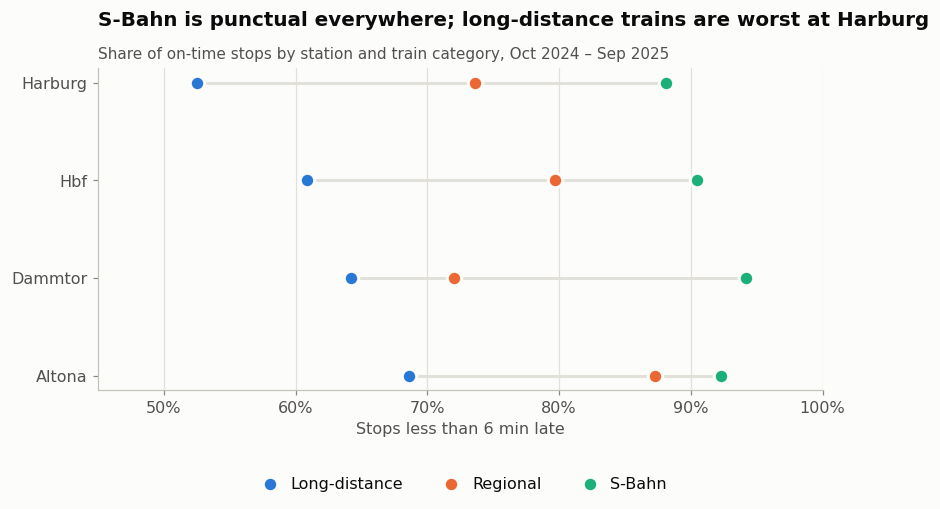

In [10]:
order = ["Hamburg-Harburg", "Hamburg Hbf", "Hamburg Dammtor", "Hamburg-Altona"]
fig, ax = plt.subplots(figsize=(8.5, 3.8))
pivot = q1_sql.pivot(index="station", columns="category", values="on_time_pct").loc[order[::-1]]
y = np.arange(len(pivot))
for i, st in enumerate(pivot.index):
    ax.plot([pivot.loc[st].min(), pivot.loc[st].max()], [i, i], color=GRID, lw=2, zorder=1)
for cat in ["Long-distance", "Regional", "S-Bahn"]:
    ax.scatter(pivot[cat], y, s=90, color=COLORS[cat], edgecolor=SURFACE, linewidth=2, zorder=3, label=cat)
ax.set_yticks(y, [s.replace("Hamburg", "").strip(" -") or s for s in pivot.index])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(45, 100)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Stops less than 6 min late")
ax.set_title("S-Bahn is punctual everywhere; long-distance trains are worst at Harburg", pad=28)
subtitle(ax, "Share of on-time stops by station and train category, Oct 2024 – Sep 2025")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.36), ncol=3, handletextpad=0.3)
fig.savefig(IMG_DIR / "01_punctuality_by_station.png")
plt.show()

**Finding:** the gap between categories is far bigger than the gap between stations. About 9 in 10 S-Bahn stops are on time, roughly 8 in 10 regional stops, but only about 6 in 10 long-distance stops — and long-distance trains are also canceled most often. Harburg, the entry point for trains from the south, has the worst long-distance punctuality of the four stations. That raises the question in Q3: are these trains *becoming* late in Hamburg, or arriving late?

## 5. Q2 — When during the day does punctuality drop?

In [11]:
q2_sql = sql("05_punctuality_by_hour.sql")

tmp = stops.dropna(subset=["delay_min"]).assign(hour=pd.to_datetime(stops.time).dt.hour)
q2_pd = (tmp.groupby(["hour", "category"]).on_time.agg(["size", "mean"]).reset_index())
check = q2_sql.merge(q2_pd, on=["hour", "category"])
assert np.allclose(check.on_time_pct, (check["mean"] * 100).round(1), atol=0.06)
print("SQL and pandas agree.")

q2_sql.pivot(index="hour", columns="category", values="on_time_pct").T

SQL and pandas agree.


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
category,,,,,,,,,,,,,,,,,,,,,
Long-distance,30.9,27.6,21.0,88.4,93.0,95.0,88.1,79.7,71.3,64.0,...,58.0,56.6,57.4,54.1,54.7,50.6,50.1,49.2,51.6,34.6
Regional,70.9,68.3,75.6,81.4,89.3,88.9,87.9,81.2,79.6,79.9,...,77.1,75.9,75.2,70.5,72.7,74.6,76.6,78.4,77.0,76.3
S-Bahn,91.5,90.2,94.0,94.5,96.9,97.0,95.8,94.3,91.2,90.9,...,92.9,91.3,88.2,86.8,85.8,86.2,89.3,90.4,90.3,89.4


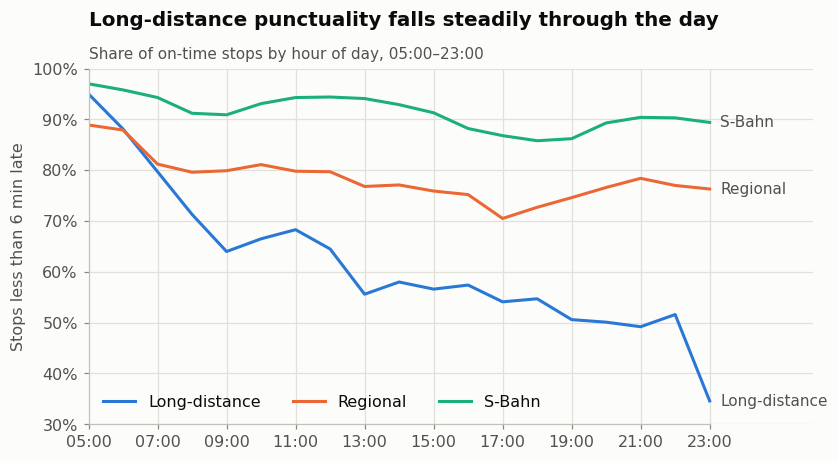

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
day = q2_sql[q2_sql.hour.between(5, 23)]
for cat in ["Long-distance", "Regional", "S-Bahn"]:
    d = day[day.category == cat]
    ax.plot(d.hour, d.on_time_pct, color=COLORS[cat], lw=2, label=cat)
    ax.text(23.3, d.on_time_pct.iloc[-1], cat, color=INK2, va="center", fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks(range(5, 24, 2), [f"{h:02d}:00" for h in range(5, 24, 2)])
ax.set_xlim(5, 26)
ax.set_ylim(30, 100)
ax.spines["bottom"].set_bounds(5, 23)
ax.set_ylabel("Stops less than 6 min late")
ax.set_title("Long-distance punctuality falls steadily through the day", pad=28)
subtitle(ax, "Share of on-time stops by hour of day, 05:00–23:00")
ax.legend(loc="lower left", ncol=3)
fig.savefig(IMG_DIR / "02_punctuality_by_hour.png")
plt.show()

**Finding:** early-morning trains are almost all on time, then long-distance punctuality slides from the morning to the evening — delays pile up over the course of the day and are never fully recovered. S-Bahn and regional trains dip in the evening rush hour (roughly 16:00–19:00) and recover afterwards.

*Note:* the drop at 23:00 and the very low long-distance values between 00:00 and 02:00 (left out of the chart) come from few stops, mostly evening trains running so late that they slipped into the night. That is a selection effect, not a "night problem".

## 6. Q3 — Are long-distance delays made in Hamburg, or imported?

`stop_number` is the position of a stop on the train's route: 1 means the train starts in Hamburg, 15 means it had already made 14 stops before arriving.

In [13]:
q3a = sql("06_delay_by_stops_travelled.sql")

ld = stops[(stops.category == "Long-distance") & stops.delay_min.notna()]
bins = pd.cut(ld.stop_number, [0, 1, 3, 6, 10, 15, np.inf], labels=q3a.stops_into_route)
q3a_pd = ld.groupby(bins, observed=True).on_time.mean().mul(100).round(1)
assert np.allclose(q3a.on_time_pct, q3a_pd.values, atol=0.06)
print("SQL and pandas agree.")
q3a.drop(columns="sort_key")

SQL and pandas agree.


,stops_into_route,stops,on_time_pct,avg_delay_min
0,1 (starts in Hamburg),28747,84.2,3.57
1,2-3,47461,77.2,4.69
2,4-6,18451,61.4,8.60
3,7-10,26131,48.9,13.86
4,11-15,29087,44.4,17.68
5,16+,23172,35.1,22.18


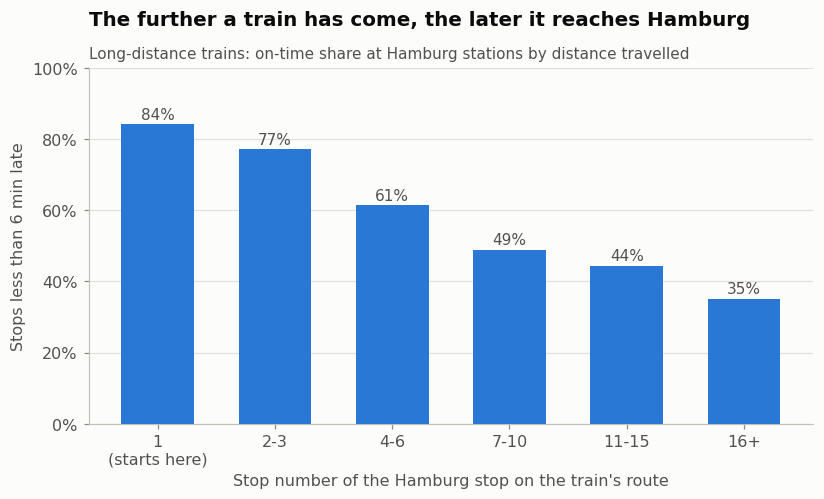

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = np.arange(len(q3a))
bars = ax.bar(x, q3a.on_time_pct, width=0.62, color=COLORS["Long-distance"], zorder=3)
for b, v in zip(bars, q3a.on_time_pct):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center", color=INK2, fontsize=10)
ax.set_xticks(x, q3a.stops_into_route.str.replace(" (starts in Hamburg)", "\n(starts here)"))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(0, 100)
ax.grid(axis="x", visible=False)
ax.set_xlabel("Stop number of the Hamburg stop on the train's route")
ax.set_ylabel("Stops less than 6 min late")
ax.set_title("The further a train has come, the later it reaches Hamburg", pad=28)
subtitle(ax, "Long-distance trains: on-time share at Hamburg stations by distance travelled")
fig.savefig(IMG_DIR / "03_imported_delay.png")
plt.show()

That pattern suggests the delay is imported. To check it directly, the next query uses `LAG()` to follow the same train from one Hamburg station to the next and measure how much delay it adds *between* them.

In [15]:
q3b = sql("07_delay_change_between_stations.sql")

# pandas mirror of the LAG() window
s = stops.dropna(subset=["delay_min"]).sort_values(["train_line_ride_id", "stop_number"])
g = s.groupby("train_line_ride_id")
s = s.assign(prev_station=g.station.shift(), prev_delay=g.delay_min.shift(), prev_num=g.stop_number.shift())
pairs = s[(s.stop_number - s.prev_num) == 1]
pairs = pairs.assign(segment=pairs.prev_station + " -> " + pairs.station, added=pairs.delay_min - pairs.prev_delay)
q3b_pd = pairs.groupby(["category", "segment"]).agg(trains=("added", "size"), added_min=("added", "mean"))
q3b_pd = q3b_pd[q3b_pd.trains >= 1000].round(2).reset_index()
check = q3b.merge(q3b_pd, on=["category", "segment"])
assert len(check) == len(q3b) and np.allclose(check.added_min_x, check.added_min_y, atol=0.006)
print("SQL and pandas agree.")
q3b

SQL and pandas agree.


,category,segment,trains,delay_before_min,delay_after_min,added_min
0,Long-distance,Hamburg Dammtor -> Hamburg-Altona,10732,19.4,18.8,-0.64
1,Long-distance,Hamburg Hbf -> Hamburg Dammtor,14067,18.0,19.3,1.26
2,Long-distance,Hamburg-Harburg -> Hamburg Hbf,17325,17.6,18.4,0.78
3,Long-distance,Hamburg Hbf -> Hamburg-Altona,4657,12.1,13.0,0.85
4,Long-distance,Hamburg Hbf -> Hamburg-Harburg,16783,4.8,7.0,2.18
5,Long-distance,Hamburg Dammtor -> Hamburg Hbf,22556,3.8,4.3,0.47
6,Long-distance,Hamburg-Altona -> Hamburg Hbf,4050,3.3,5.7,2.40
7,Long-distance,Hamburg-Altona -> Hamburg Dammtor,12950,2.0,3.1,1.02
8,Regional,Hamburg Dammtor -> Hamburg Hbf,19429,6.7,6.5,-0.20
9,Regional,Hamburg-Harburg -> Hamburg Hbf,24722,5.4,5.6,0.19


**Finding:** long-distance trains coming in via Harburg already carry an average delay of about 18 minutes, but add less than 1 minute on the way to the Hbf. Between any two Hamburg stations, trains add at most around 2 minutes on average — small compared with the delay they bring with them. **Most of the long-distance delay seen in Hamburg is created elsewhere on the network.** The largest in-Hamburg increases are on the segments into and out of the Hbf, one of the busiest stations in Germany.

## 7. Q4 — Which regional and S-Bahn lines are the least reliable?

In [16]:
q4 = sql("08_line_ranking.sql")

q4_pd = (
    stops[stops.category.isin(["Regional", "S-Bahn"]) & stops.delay_min.notna()]
    .groupby(["category", "line"]).on_time.agg(["size", "mean"])
    .query("size >= 2000").reset_index()
)
check = q4.merge(q4_pd, on=["category", "line"])
assert len(check) == len(q4) and np.allclose(check.on_time_pct, (check["mean"] * 100).round(1), atol=0.06)
print("SQL and pandas agree.")
q4

SQL and pandas agree.


,category,line,stops,on_time_pct,avg_delay_min,rank_worst_first
0,Regional,RB31,26589,65.2,5.92,1
1,Regional,RE7,37432,69.2,4.99,2
2,Regional,RB41,27425,71.7,5.01,3
3,Regional,RE3,23219,74.2,4.64,4
4,Regional,RB61,21559,74.9,4.08,5
5,Regional,RE4,20827,76.4,4.32,6
6,Regional,RE1,10383,76.8,4.82,7
7,Regional,RE70,21471,76.8,4.27,7
8,Regional,RB38,2084,80.1,3.72,9
9,Regional,RE6,11045,84.8,3.02,10


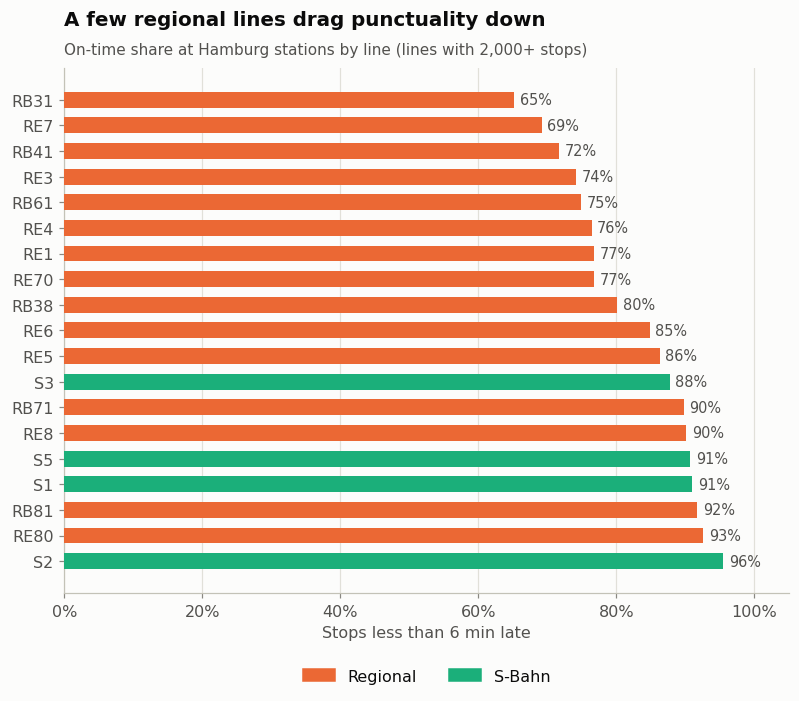

In [17]:
d = q4.sort_values("on_time_pct", ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 6.2))
y = np.arange(len(d))
ax.barh(y, d.on_time_pct, height=0.62, color=[COLORS[c] for c in d.category], zorder=3)
for yi, v in zip(y, d.on_time_pct):
    ax.text(v + 0.8, yi, f"{v:.0f}%", va="center", color=INK2, fontsize=9.5)
ax.set_yticks(y, d.line)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 105)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Stops less than 6 min late")
handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[c]) for c in ["Regional", "S-Bahn"]]
ax.legend(handles, ["Regional", "S-Bahn"], loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=2)
ax.set_title("A few regional lines drag punctuality down", pad=28)
subtitle(ax, "On-time share at Hamburg stations by line (lines with 2,000+ stops)")
fig.savefig(IMG_DIR / "04_line_ranking.png")
plt.show()

**Finding:** three regional lines — RB31, RE7 and RB41 — are clearly the weakest, with 28–35% of stops late. At the other end, the S2 and several regional lines (RE80, RB81, RE8) are on time more than 90% of the time, so "regional" is not unreliable by definition: it depends on the line.

## 8. Summary

- **Train type matters more than station.** S-Bahn stops are on time about 9 times in 10, long-distance stops about 6 times in 10.
- **Long-distance delay is mostly imported.** Punctuality falls sharply with the number of stops a train made before Hamburg, while trains add only a small amount of delay between Hamburg stations.
- **Delay builds up during the day.** Long-distance punctuality falls from near-perfect early in the morning to its lowest in the evening.
- **Reliability is line-specific.** RB31, RE7 and RB41 are late on 28–35% of stops, while other regional lines match the S-Bahn.

**What this means for a passenger:** when a connection matters, an S-Bahn or a train that starts in Hamburg is far more predictable than a long-distance train that has already crossed half the country.

## 9. Limitations and next steps

- **March 2025 is missing** from the source data; the other 11 months are complete.
- **Punctuality here is per stop, not per passenger.** A full ICE and an empty late-night regional train count the same.
- **The delay shown is departure delay** (arrival delay at a train's final stop), which is how the source defines it — not the delay a passenger experiences at the end of their journey.
- **Next steps:** join construction-work schedules to explain the monthly dips, and extend the analysis to the whole route of the worst regional lines to find where they lose their time.

In [18]:
conn.close()